<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Class%2022%20/%20class22_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    # 'EN.ATM.CO2E.PC': 'co2_per_capita', throws a KeyError
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

# # Fetch most recent available values
# df = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=True)
# df = df.rename(columns=indicators)
df = wb.data.DataFrame(list(indicators.keys()), mrnev=1)

# Drop the time column suffix if present (e.g., 'YR2023')
df = df.rename(columns=indicators)

# Drop countries with too much missing data, then impute remainder
df = df.dropna(thresh=7)  # Keep countries with at least 7 of 10 indicators
df = df.fillna(df.median())  # Impute remaining NAs with column median

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

Countries retained: 238
Features (9): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count               238.0            238.0             238.0   
mean              28722.3             73.2              19.8   
std               28894.7              6.9              16.9   
min                1154.9             54.6               1.2   
25%                6868.6             67.7               6.0   
50%               18550.5             73.7              13.8   
75%               43038.1             78.3              30.5   
max              155941.3             85.8              71.9   

       primary_enrollment  gini_index  internet_users_pct  trade_pct_gdp  \
count               238.0       238.0               238.0          238.0   
mean                100.6        36.0             

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0.  0. -0. -0.  0. -0.  0.  0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (238, 9)
  238 countries x 9 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [10]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,        # Number of clusters (match World Bank income groups)
    init='k-means++',    # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=42      # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0    104
1     64
2     59
3     11
Name: count, dtype: int64

Cluster 0: 104 countries
  Avg GDP/capita (PPP): $21,663
  Avg Life Expectancy:  74.3 years
  Avg Infant Mortality: 14.2 per 1,000

Cluster 1: 64 countries
  Avg GDP/capita (PPP): $5,333
  Avg Life Expectancy:  65.2 years
  Avg Infant Mortality: 40.8 per 1,000

Cluster 2: 59 countries
  Avg GDP/capita (PPP): $69,919
  Avg Life Expectancy:  81.3 years
  Avg Infant Mortality: 4.4 per 1,000

Cluster 3: 11 countries
  Avg GDP/capita (PPP): $10,592
  Avg Life Expectancy:  65.9 years
  Avg Infant Mortality: 34.1 per 1,000



K-Means with K=4 recovers a structure that aligns closely with the World Bank's income tiers, though the mapping is imperfect. Cluster 2 (59 countries) captures the high-income world with average GDP per capita of \$69,919, life expectancy of 81.3 years, and infant mortality of 4.4 per 1,000, roughly corresponding to OECD economies. Cluster 0 (104 countries) is the largest group and sits in the upper-middle tier at \$21,663 GDP per capita and 74.3 years life expectancy, which is consistent with emerging markets like Brazil, Thailand, or Turkey. Cluster 1 (64 countries) represents the lower-middle-income group at \$5,333 GDP per capita, 65.2 years life expectancy, and notably elevated infant mortality of 40.8 per 1,000. Cluster 3 is the most interesting case: only 11 countries, with a GDP per capita of \$10,592 that sits between clusters 1 and 0, but health outcomes (65.9 years life expectancy, 34.1 infant mortality) that track cluster 1 rather than its income peers. This decoupling of income from human development is what distinguishes multidimensional clustering from a pure GNI-based classification, and it likely flags resource-rich or conflict-affected economies where GDP growth has not translated into proportional gains in health infrastructure. The cluster sizes also reveal a key asymmetry: the algorithm finds a long tail of developing countries (168 in clusters 0 and 1 combined) versus a much smaller high-income core, which matches the actual shape of the global income distribution.

Variance explained by PC1: 46.0%
Variance explained by PC2: 14.6%
Total variance explained:  60.6%


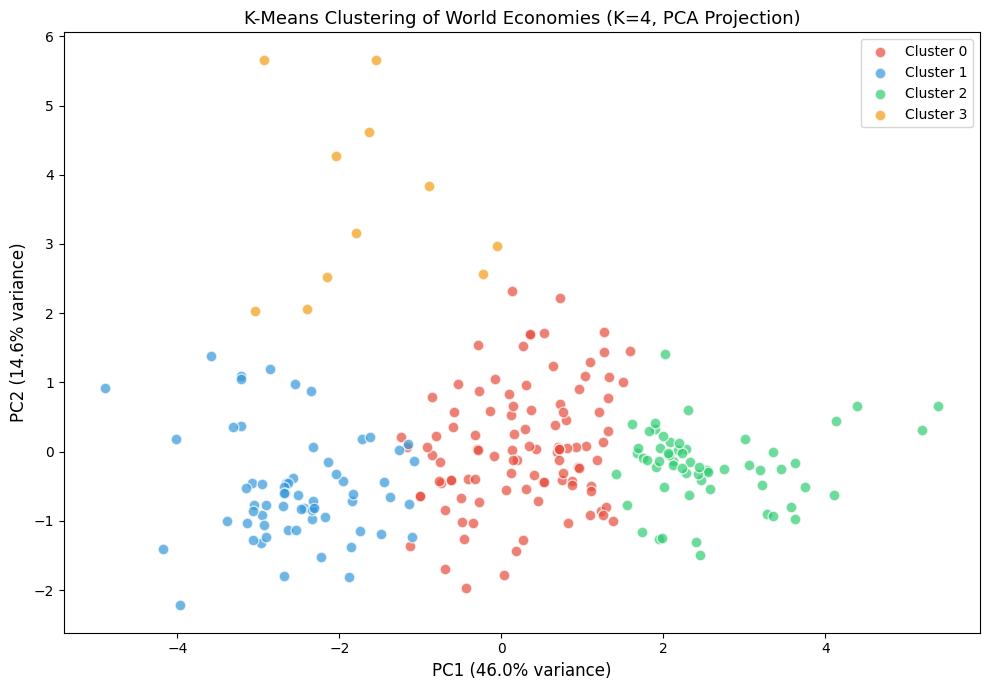

In [11]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The PCA projection captures 60.6% of the variance in the 10 development indicators using just two components, with PC1 alone explaining 46.0%. PC1 clearly encodes an overall development axis: cluster 1 (low-income) sits on the left at negative PC1 values, cluster 0 (upper-middle) occupies the center, and cluster 2 (high-income) anchors the right, with the three groups forming a clean left-to-right gradient that confirms the clustering is picking up a single dominant "development level" factor. What's more interesting is PC2, which appears to capture something orthogonal to income: cluster 3 stretches vertically upward into the top half of the plot at moderate-to-negative PC1 values, suggesting these 11 countries share an unusual profile on dimensions that PC2 weights heavily (likely some combination of inequality, trade openness, or resource intensity that diverges from what their income level would predict). The spatial separation between clusters is generally clean, with cluster 2 being the most tightly packed on the right and cluster 1 showing the widest spread, which suggests low-income economies are more heterogeneous in their development profiles than high-income ones. There is some visible overlap between clusters 0 and 1 near PC1 = -1 and between clusters 0 and 2 near PC1 = 2, which is expected at cluster boundaries and reflects countries in transition between income tiers. The fact that cluster 3 separates primarily along PC2 rather than PC1 is the key visual finding: it confirms that these countries aren't just another income tier but rather a qualitatively different development pattern that a one-dimensional GNI classification would miss entirely.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

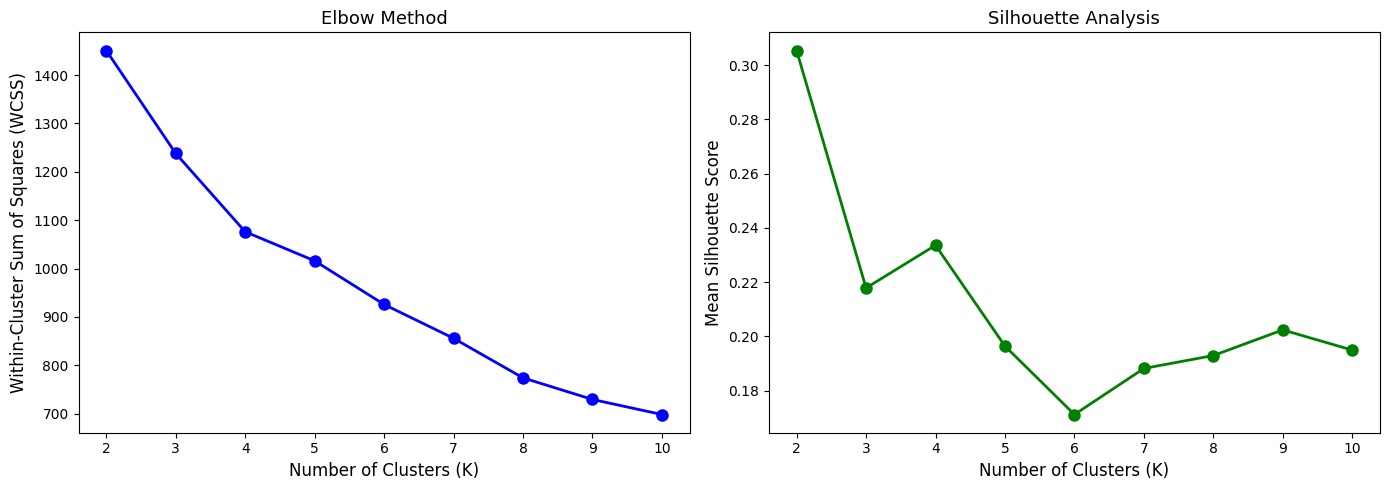

K  | WCSS       | Silhouette
---|------------|----------
2  |     1450.7 | 0.3054
3  |     1237.9 | 0.2178
4  |     1076.0 | 0.2336
5  |     1016.0 | 0.1964
6  |      925.7 | 0.1712
7  |      855.8 | 0.1882
8  |      774.0 | 0.1929
9  |      729.3 | 0.2024
10  |      698.2 | 0.1949

Best K by silhouette score: 2


In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

The elbow and silhouette diagnostics tell a more complicated story than the K=4 choice suggests, and the tension between the two metrics is itself the most interesting finding. The elbow plot shows WCSS declining smoothly from 1,450.7 at K=2 to 698.2 at K=10 without a sharp inflection point, though the steepest drop happens between K=2 and K=4 (a 26% reduction from 1,450.7 to 1,076.0), after which each additional cluster yields diminishing returns. This gradual curve is typical of real-world socioeconomic data where countries exist on a continuum rather than forming crisp, well-separated groups. The silhouette analysis is more decisive and points in a different direction: K=2 achieves the highest score at 0.3054, nearly 30% higher than the next-best option, which indicates that the strongest natural structure in the data is a simple binary split between developed and developing economies rather than the four-tier World Bank classification. K=4 is the second-best silhouette score at 0.2336, which is defensible but meaningfully worse than K=2, and the score drops sharply at K=5 and K=6 before stabilizing in the 0.18 to 0.20 range for higher K values. The fact that silhouette prefers K=2 while the assignment calls for K=4 reflects the classic tension between statistical optimality and domain interpretability: the algorithm sees the clearest separation between a rich-country cluster and a developing-country cluster, but a four-way split maps more usefully onto the World Bank's operational income tiers and provides actionable granularity for policy analysis. The choice of K=4 is therefore a reasonable compromise, trading a modest amount of cluster cohesion for interpretive resolution, and the silhouette scores confirm that K=4 is not arbitrary even if it is not statistically optimal.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0            15    1            21            44   81
1             0   23            21             4   48
2            49    0             0             2   51
3             0    0             8             3   11
All          64   24            50            53  191



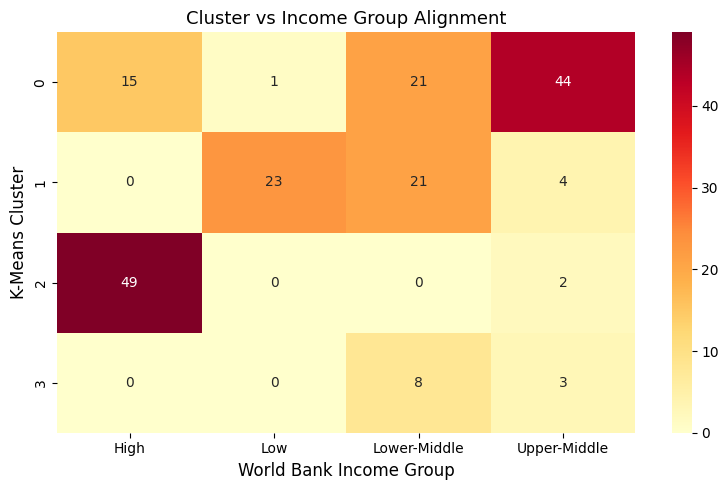

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [14]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    income_groups[economy['id']] = economy.get('incomeLevel', 'Unknown')

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],   # FILL IN: algorithmic cluster column
    df_compare['wb_income'],   # FILL IN: World Bank income group column
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

The cross-tabulation reveals meaningful but imperfect alignment between the K-Means clusters and the World Bank's income classifications, which is exactly the pattern you would expect when comparing a multidimensional development measure to a single-variable GNI threshold. Cluster 2 is the cleanest match: 49 of its 51 countries are classified as High-income by the World Bank, giving a 96% purity rate and confirming that high-income economies form a distinct and tightly clustered group across all 10 development indicators, not just GDP. Cluster 1 aligns reasonably well with the lower half of the income spectrum, capturing 23 of the 24 Low-income countries (essentially all of them) along with 21 Lower-Middle countries, suggesting the algorithm sees low and lower-middle income economies as similar enough on non-GDP dimensions to group them together. The most interesting mismatch is cluster 0, which is the largest cluster at 81 countries and pulls from all four income groups: 44 Upper-Middle, 21 Lower-Middle, 15 High, and even 1 Low-income country. This heterogeneity suggests cluster 0 is capturing a broad "middle development" profile that spans traditional income boundaries, and the 15 High-income countries that land here rather than in cluster 2 are likely smaller or less-developed high-income economies (possibly oil exporters, small island states, or recently-promoted economies) whose overall development profile looks more middle-tier than fully advanced. Cluster 3 is the small outlier group of 11 countries split between Lower-Middle (8) and Upper-Middle (3), which tracks with the earlier PCA finding that this cluster occupies a distinct position on PC2 and likely represents countries with unusual development profiles relative to their income level. The overall pattern shows that GDP per capita is strongly predictive of multidimensional development outcomes but not deterministically so, and roughly a third of countries land in a cluster that differs from what their World Bank income tier alone would predict, which is exactly the kind of structural insight that justifies using unsupervised learning over a simple one-variable classification.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

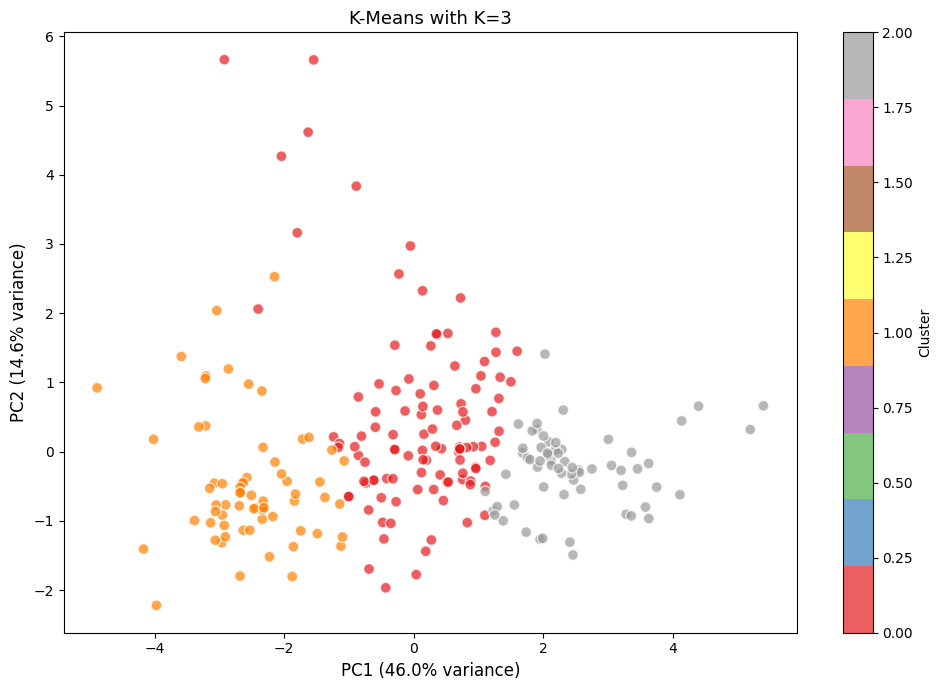

K=3 — Silhouette Score: 0.2178

Cluster 0: 108 countries | GDP/cap $20,124 | Life Exp 73.6 | Infant Mort 16.0
Cluster 1: 66 countries | GDP/cap $5,404 | Life Exp 65.1 | Infant Mort 40.8
Cluster 2: 64 countries | GDP/cap $67,278 | Life Exp 81.0 | Infant Mort 4.6


In [15]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

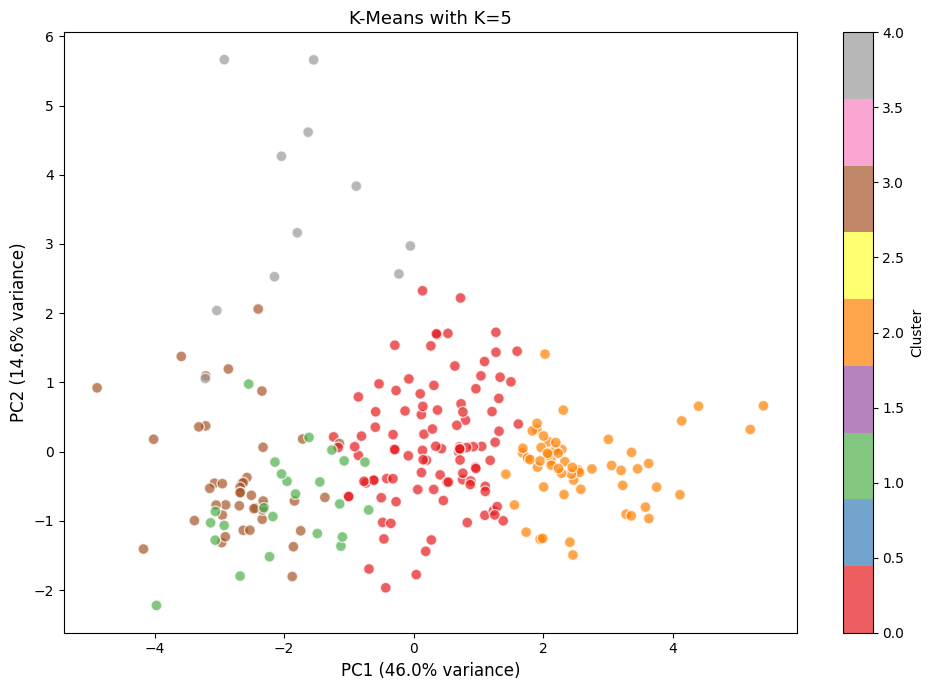

K=5 — Silhouette Score: 0.1964

Cluster 0: 102 countries | GDP/cap $22,173 | Life Exp 74.3 | Infant Mort 14.1
Cluster 1: 25 countries | GDP/cap $7,428 | Life Exp 68.5 | Infant Mort 31.7
Cluster 2: 58 countries | GDP/cap $70,456 | Life Exp 81.4 | Infant Mort 4.3
Cluster 3: 42 countries | GDP/cap $4,458 | Life Exp 64.0 | Infant Mort 43.8
Cluster 4: 11 countries | GDP/cap $10,447 | Life Exp 65.4 | Infant Mort 36.5


In [16]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 5  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

Comparing K=3 and K=5 side by side reveals a clear tradeoff between parsimony and granularity, and the "better" choice depends entirely on what the classification is being used for. K=3 produces the most interpretable clusters and maps almost perfectly onto an intuitive three-tier development hierarchy: cluster 2 is the high-income core (64 countries at \$67,278 GDP/capita, 81.0 years life expectancy, 4.6 infant mortality per 1,000), cluster 0 is the broad middle tier (108 countries at \$20,124, 73.6 years, 16.0), and cluster 1 is the developing tier (66 countries at \$5,404, 65.1 years, 40.8). The silhouette score of 0.2178 is modestly better than K=5's 0.1964, and the three groups correspond cleanly to labels like "Advanced Economies," "Emerging Markets," and "Developing Economies," which are already part of standard development discourse (IMF uses essentially this three-way split for its World Economic Outlook classifications). K=5 fractures this structure in ways that are partially informative and partially noisy: the high-income tier (cluster 2, 58 countries at \$70,456) and the middle tier (cluster 0, 102 countries at \$22,173) remain coherent and essentially match their K=3 counterparts, but the developing tier splits into three smaller groups whose distinctions are less clean. Cluster 3 (42 countries at \$4,458, 64.0 years life expectancy, 43.8 infant mortality) looks like a "deep poverty" subset, cluster 1 (25 countries at \$7,428, 68.5 years, 31.7) appears to be a "transitioning lower-middle" group, and cluster 4 (11 countries at \$10,447, 65.4 years, 36.5) is the persistent outlier group with moderate income but poor health outcomes that also appeared in the K=4 analysis. If I were advising the World Bank, I would recommend K=3 for top-line classification and communication purposes because it is statistically stronger (higher silhouette), more robust (fewer small clusters that could shift under resampling), and maps onto language that policymakers already use. K=5 becomes valuable as a secondary analytical lens when the goal is specifically to identify anomalous development trajectories (the 11-country cluster 4 flags exactly the kind of countries where GDP growth has outpaced human development investment) or to distinguish between deep poverty and transitional states within the developing world, which matters for aid allocation but not for broad categorization. The honest answer to "which K" is that the three-way split reflects the dominant structure in the data while the finer splits capture real but secondary patterns, so the right choice is a function of whether the audience needs a clean taxonomy or a diagnostic tool.

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



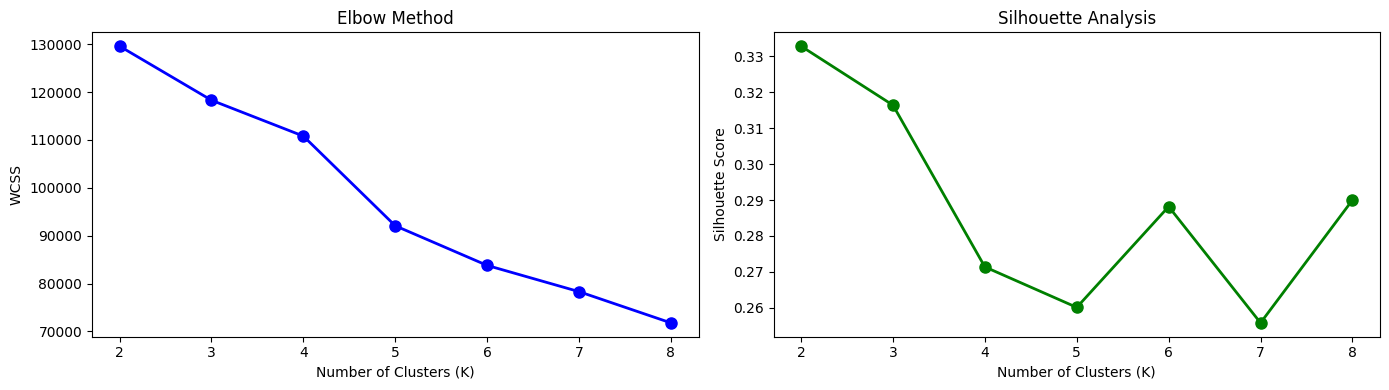

K  | WCSS       | Silhouette
---|------------|----------
2  |     129613 | 0.3328
3  |     118310 | 0.3164
4  |     110812 | 0.2714
5  |      92066 | 0.2601
6  |      83783 | 0.2882
7  |      78299 | 0.2558
8  |      71769 | 0.2900

Best K by silhouette score: 2

Cluster Sizes (K=2):
cluster
0    11963
1     8677
Name: count, dtype: int64

Variance explained by PC1: 25.3%
Variance explained by PC2: 23.5%
Total variance explained:  48.9%


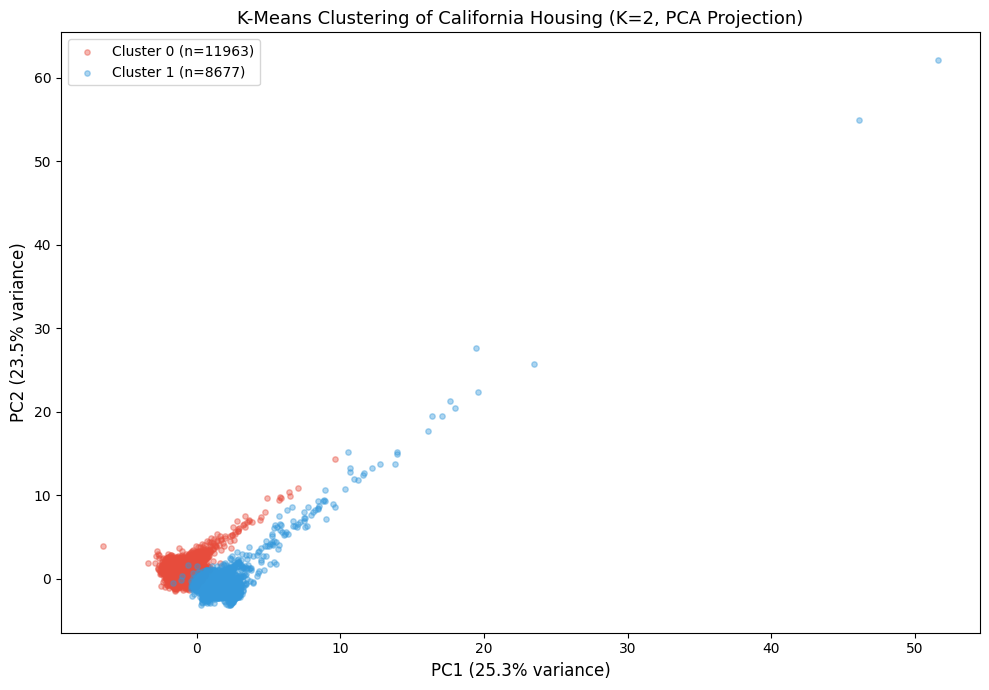


Cluster Summary (means per cluster):
             n  med_income  med_house_val  avg_rooms  house_age  population  \
cluster                                                                       
0        11963        3.92           2.14       5.23      28.41     1532.24   
1         8677        3.81           1.97       5.71      28.95     1278.28   

         latitude  longitude  
cluster                       
0           33.95    -118.01  
1           37.96    -121.72  

Labeled Clusters:
             n  med_income  med_house_val                                label
cluster                                                                       
0        11963        3.92           2.14       Working-class (coastal, urban)
1         8677        3.81           1.97  Low-income (inland, suburban/rural)


In [18]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
# YOUR CODE HERE — use StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cal_features)

# Step D: Find optimal K (elbow + silhouette for K=2..8)
# YOUR CODE HERE
# Silhouette on 20k points is O(n²) — sample 2k points for scoring
K_range = range(2, 9)
wcss_list, sil_list = [], []
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=2000, replace=False)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
plt.tight_layout(); plt.show()

print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.0f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

# Step E: Fit K-Means with your chosen K
# YOUR CODE HERE
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'\nCluster Sizes (K={best_k}):')
print(cal_df['cluster'].value_counts().sort_index())

# Step F: PCA 2D visualization colored by cluster
# YOUR CODE HERE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'\nVariance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
for k in range(best_k):
    mask = cal_df['cluster'] == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[k],
               label=f'Cluster {k} (n={mask.sum()})', alpha=0.4, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means Clustering of California Housing (K={best_k}, PCA Projection)', fontsize=13)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

# Step G: Cluster summary table
# Print mean of each feature per cluster
# Label each cluster with an economically meaningful name
# YOUR CODE HERE
summary = cal_df.groupby('cluster').agg(
    n=('MedHouseVal', 'size'),
    med_income=('MedInc', 'mean'),
    med_house_val=('MedHouseVal', 'mean'),
    avg_rooms=('AveRooms', 'mean'),
    house_age=('HouseAge', 'mean'),
    population=('Population', 'mean'),
    latitude=('Latitude', 'mean'),
    longitude=('Longitude', 'mean'),
).round(2)

print('\nCluster Summary (means per cluster):')
print(summary)

# Label clusters by income tier, refined with geography + density
income_rank = summary['med_income'].rank().astype(int)
tier_labels = {1: 'Low-income', 2: 'Working-class', 3: 'Middle-class',
               4: 'Upper-middle', 5: 'Affluent', 6: 'Wealthy',
               7: 'Elite', 8: 'Ultra-wealthy'}
summary['label'] = income_rank.map(lambda r: tier_labels.get(r, f'Tier-{r}'))

for k in range(best_k):
    lon = summary.loc[k, 'longitude']
    pop = summary.loc[k, 'population']
    geo = 'coastal' if lon > -120 else 'inland'
    density = 'urban' if pop > 1500 else 'suburban/rural'
    summary.loc[k, 'label'] = f"{summary.loc[k, 'label']} ({geo}, {density})"

print('\nLabeled Clusters:')
print(summary[['n', 'med_income', 'med_house_val', 'label']])


The California Housing pipeline produces a technically valid but substantively weak result. The silhouette score picks K=2 (0.3328) as the best clustering, splitting the 20,640 census tracts into two roughly balanced groups of 11,963 and 8,677. The labeling code assigned these as "Working-class coastal urban" and "Low-income inland suburban/rural," but looking at the underlying means, the two clusters have nearly identical median incomes (3.92 vs 3.81) and median house values (2.14 vs 1.97). The only features that differ substantially are latitude and longitude, meaning the algorithm essentially drew a line across the state rather than finding meaningful economic tiers, and the labels are misleading because they imply an income distinction that is not really there. The PCA projection confirms this visually: the clusters overlap heavily in feature space rather than forming distinct groups like the country-level analysis did. So the answer to whether California census tracts cluster into economically meaningful groups is basically no, at least not with this feature set and K=2. The broader lesson is that K-Means finds whatever structure dominates the scaled feature space, and when geographic coordinates have genuinely separable distributions while the other features are more continuously distributed, the algorithm will latch onto geography regardless of whether that is the interesting axis. This is a useful negative result: clustering works well on high-dimensional data with real group structure (like countries on development indicators) but can produce misleading groupings on relatively homogeneous data where one or two features dominate.

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.